In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("../data/processed/clean_network.csv")
print("Shape:", df.shape)
df.head()


Shape: (82332, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,normal,0


In [3]:
def bucket_bytes(x):
    if x < 1e3: return "tiny"
    elif x < 1e4: return "small"
    elif x < 1e5: return "medium"
    elif x < 1e6: return "large"
    else: return "huge"

def row_to_text(row):
    toks = []
    if "proto" in row: toks.append(f"proto_{row['proto']}")
    if "sport" in row: toks.append(f"srcp_{row['sport']}")
    if "dport" in row: toks.append(f"dstp_{row['dport']}")
    if "bytes" in row: toks.append(f"bytes_{bucket_bytes(float(row['bytes']))}")
    if "pkts"  in row: toks.append(f"pkts_{int(row['pkts'])//10}")
    return " ".join(map(str, toks))

# Select subset of columns for speed
keep_cols = [c for c in df.columns if c in ["proto","sport","dport","bytes","pkts","label"]]
df = df[keep_cols].copy()
df["text"] = df.apply(row_to_text, axis=1)
df[["text","label"]].head()


,text,label
0,proto_udp,0
1,proto_udp,0
2,proto_udp,0
3,proto_udp,0
4,proto_udp,0


In [4]:
from collections import Counter

texts = df["text"].astype(str).tolist()
labels = df["label"].astype(int).values

token_lists = [t.split() for t in texts]
vocab = {"[PAD]":0, "[UNK]":1}
for tok, _ in Counter(tok for row in token_lists for tok in row).items():
    vocab[tok] = len(vocab)

vocab_size = len(vocab)
print("Vocab size:", vocab_size)


Vocab size: 133


In [5]:
def encode(tokens, max_len=16):
    ids = [vocab.get(t,1) for t in tokens][:max_len]
    ids += [0]*(max_len - len(ids))
    return ids

X = np.array([encode(toks) for toks in token_lists])
y = labels

print("Encoded shape:", X.shape)


Encoded shape: (82332, 16)


In [6]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_val,   X_test, y_val, y_test   = train_test_split(X_temp, y_temp, test_size=2/3, stratify=y_temp, random_state=42)

print(len(X_train), len(X_val), len(X_test))


57632 8233 16467


In [7]:
class TokenDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

train_ds = TokenDataset(X_train, y_train)
val_ds   = TokenDataset(X_val, y_val)
test_ds  = TokenDataset(X_test, y_test)

train_dl = DataLoader(train_ds, batch_size=256, shuffle=True)
val_dl   = DataLoader(val_ds, batch_size=512)
test_dl  = DataLoader(test_ds, batch_size=512)


In [8]:
class TinyTransformer(nn.Module):
    def __init__(self, vocab_size, d_model=64, nhead=4, num_layers=2, num_classes=2, max_len=16):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, d_model)
        self.pos   = nn.Embedding(max_len, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model, nhead, dim_feedforward=128, batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers)
        self.fc = nn.Linear(d_model, num_classes)

    def forward(self, x):
        B, T = x.shape
        pos = torch.arange(T).unsqueeze(0).repeat(B,1).to(x.device)
        h = self.embed(x) + self.pos(pos)
        h = self.encoder(h)
        h_cls = h[:,0,:]
        return self.fc(h_cls)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = TinyTransformer(vocab_size=vocab_size).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()


In [ ]:
def run_epoch(dl, train=True):
    model.train(train)
    total_loss, correct, n = 0, 0, 0
    for xb, yb in dl:
        xb, yb = xb.to(device), yb.to(device)
        if train: optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        if train:
            loss.backward()
            optimizer.step()
        total_loss += loss.item()*xb.size(0)
        correct += (out.argmax(1)==yb).sum().item()
        n += xb.size(0)
    return total_loss/n, correct/n

for epoch in range(10):
    tr_loss, tr_acc = run_epoch(train_dl, True)
    val_loss, val_acc = run_epoch(val_dl, False)
    print(f"Epoch {epoch+1:02d} | Train loss={tr_loss:.4f} acc={tr_acc:.3f} | Val loss={val_loss:.4f} acc={val_acc:.3f}")

torch.save(model.state_dict(), "../models/transformer.pth")
print("Transformer model saved.")


Epoch 01 | Train loss=0.5630 acc=0.713 | Val loss=0.5582 acc=0.710
Epoch 02 | Train loss=0.5542 acc=0.718 | Val loss=0.5570 acc=0.711
Epoch 03 | Train loss=0.5532 acc=0.718 | Val loss=0.5565 acc=0.711
Epoch 04 | Train loss=0.5530 acc=0.718 | Val loss=0.5571 acc=0.711
Epoch 05 | Train loss=0.5528 acc=0.718 | Val loss=0.5572 acc=0.711
Epoch 06 | Train loss=0.5530 acc=0.718 | Val loss=0.5566 acc=0.711
Epoch 07 | Train loss=0.5520 acc=0.718 | Val loss=0.5564 acc=0.711
Epoch 08 | Train loss=0.5524 acc=0.718 | Val loss=0.5574 acc=0.711
Epoch 09 | Train loss=0.5519 acc=0.718 | Val loss=0.5572 acc=0.711
Epoch 10 | Train loss=0.5517 acc=0.718 | Val loss=0.5600 acc=0.711
✅ Transformer model saved.


In [10]:
import torch.nn.functional as F

def predict_probs(dl):
    all_probs, all_labels = [], []
    model.eval()
    with torch.no_grad():
        for xb, yb in dl:
            xb = xb.to(device)
            probs = F.softmax(model(xb), dim=1)[:,1].cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(yb.numpy())
    return np.array(all_probs), np.array(all_labels)

y_prob, y_true = predict_probs(test_dl)


In [11]:
best_f1, best_t = 0, 0
for t in np.linspace(0.1, 0.9, 17):
    preds = (y_prob >= t).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(y_true, preds, average="binary", zero_division=0)
    if f1 > best_f1:
        best_f1, best_t, best_p, best_r = f1, t, p, r

print(f"Best threshold: {best_t:.2f}")
print(f"Precision: {best_p:.3f} | Recall: {best_r:.3f} | F1: {best_f1:.3f}")


Best threshold: 0.35
Precision: 0.780 | Recall: 0.667 | F1: 0.719


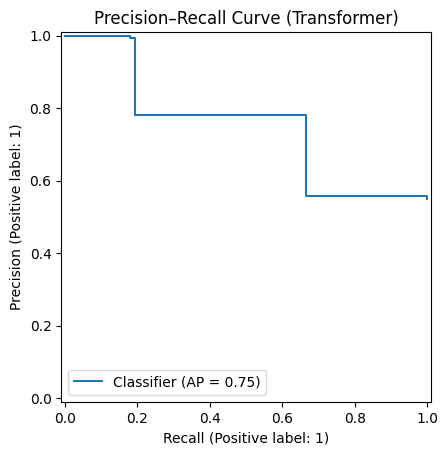

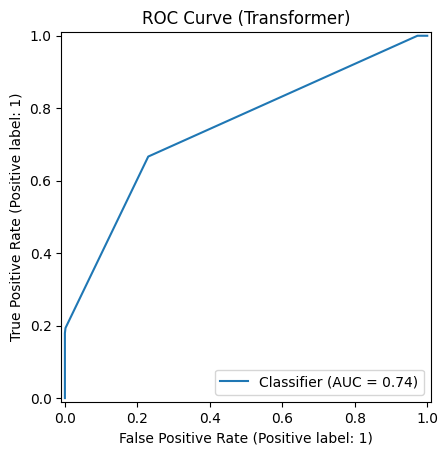

In [12]:
PrecisionRecallDisplay.from_predictions(y_true, y_prob)
plt.title("Precision–Recall Curve (Transformer)")
plt.show()

RocCurveDisplay.from_predictions(y_true, y_prob)
plt.title("ROC Curve (Transformer)")
plt.show()


In [13]:
pd.DataFrame({"actual": y_true, "prob": y_prob}).to_csv("../data/processed/transformer_predictions.csv", index=False)
print("✅ Predictions saved at data/processed/transformer_predictions.csv")


✅ Predictions saved at data/processed/transformer_predictions.csv


In [8]:
import os, torch
os.makedirs("../models", exist_ok=True)
torch.save(model.state_dict(), "../models/transformer_model.pth")
print("✅ Model saved at ../models/transformer_model.pth")


✅ Model saved at ../models/transformer_model.pth


In [9]:
import pandas as pd, os
os.makedirs("../data/processed", exist_ok=True)
pd.DataFrame(X_encoded.columns, columns=["columns"]).to_csv("../data/processed/X_columns.csv", index=False)
print("✅ Saved column reference file with", len(X_encoded.columns), "columns.")


✅ Saved column reference file with 197 columns.


In [10]:
import pandas as pd, os
os.makedirs("../data/processed", exist_ok=True)
pd.DataFrame(X_encoded.columns, columns=['columns']).to_csv("../data/processed/X_columns.csv", index=False)
print("✅ Saved training column reference file with", len(X_encoded.columns), "columns.")


✅ Saved training column reference file with 197 columns.


In [11]:
import os
import joblib

# Create folder if not exists
os.makedirs("../models", exist_ok=True)

# Save the fitted scaler used during training
joblib.dump(scaler, "../models/scaler.pkl")

print("✅ Trained StandardScaler saved successfully at ../models/scaler.pkl")


✅ Trained StandardScaler saved successfully at ../models/scaler.pkl
